# Modélisation — Détection de Tweets Suspects
## Comparaison de 3 algorithmes de classification

Ce notebook détaille l'ensemble de la phase de modélisation :
- Représentation TF-IDF
- Entraînement de 3 modèles (Logistic Regression, Naive Bayes, Random Forest)
- Comparaison visuelle des performances
- Matrices de confusion et courbes ROC
- Validation croisée 5-fold
- Optimisation des hyperparamètres (Grid Search)
- Analyse des erreurs et importance des features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import os
sys.path.append("..")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
)
plt.style.use("ggplot")


---
## 1. Chargement des données prétraitées

In [2]:
df = pd.read_csv("../data/processed/tweets_clean.csv")
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"Distribution des classes : {df['label'].value_counts().to_dict()}")
ratio = df['label'].value_counts()[0] / df['label'].value_counts()[1]
print(f"Ratio desequilibre : {ratio:.2f}:1")
df.head()

Shape : (59654, 3)
Colonnes : ['message', 'label', 'clean_message']
Distribution des classes : {1: 53509, 0: 6145}
Ratio desequilibre : 0.11:1


,message,label,clean_message
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1,bummer shoulda get david carr third day
1,is upset that he can't update his Facebook by ...,1,upset cannot update facebook texting might cry...
2,@Kenichan I dived many times for the ball. Man...,1,dive many time ball manage save rest bound
3,my whole body feels itchy and like its on fire,0,whole body feel itchy like fire
4,"@nationwideclass no, it's not behaving at all....",1,behaving mad cannot see


---
## 2. Représentation TF-IDF

In [3]:
X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Train : {X_train_vec.shape}  |  Test : {X_test_vec.shape}")
print(f"Vocabulaire : {len(vectorizer.vocabulary_)} termes uniques")

Train : (47723, 5000)  |  Test : (11931, 5000)
Vocabulaire : 5000 termes uniques


---
## 3. Entraînement des 3 modèles

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
}

results = []
predictions = {}

for name, model in models.items():
    print(f"Entrainement : {name}...")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    y_proba = model.predict_proba(X_test_vec)[:, 1] if hasattr(model, "predict_proba") else y_pred.astype(float)
    predictions[name] = {"y_true": y_test, "y_pred": y_pred, "y_proba": y_proba}
    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)
    results.append({"Modele": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

results_df = pd.DataFrame(results)
results_df

Entrainement : Logistic Regression...


Entrainement : Naive Bayes...
Entrainement : Random Forest...


,Modele,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9639,0.9776,0.9822,0.9799
1,Naive Bayes,0.9289,0.9269,0.9995,0.9619
2,Random Forest,0.9711,0.9777,0.9904,0.9840


---
## 4. Comparaison visuelle des performances

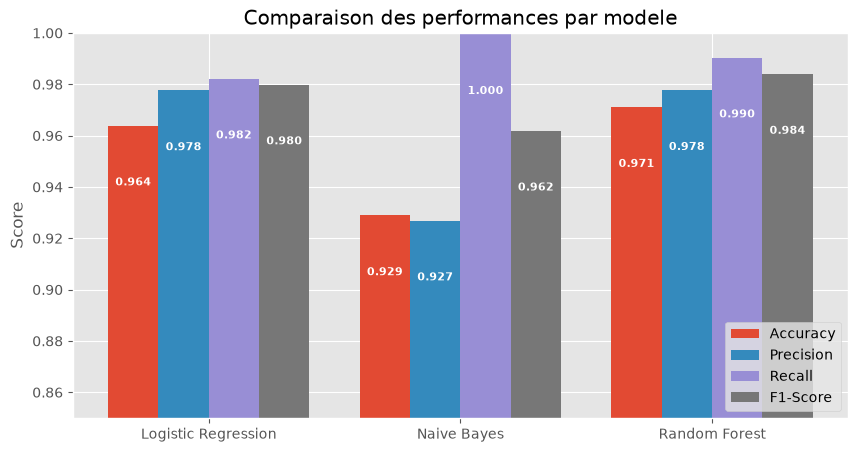

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_list = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(results_df))
width = 0.2
for i, m in enumerate(metrics_list):
    bars = ax.bar(x + i * width, results_df[m], width, label=m)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
                f"{bar.get_height():.3f}", ha="center", va="top",
                fontsize=8, color="white", fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Modele"])
ax.set_ylabel("Score")
ax.set_title("Comparaison des performances par modele")
ax.set_ylim(0.85, 1.0)
ax.legend(loc="lower right")
plt.savefig("../reports/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Matrices de confusion

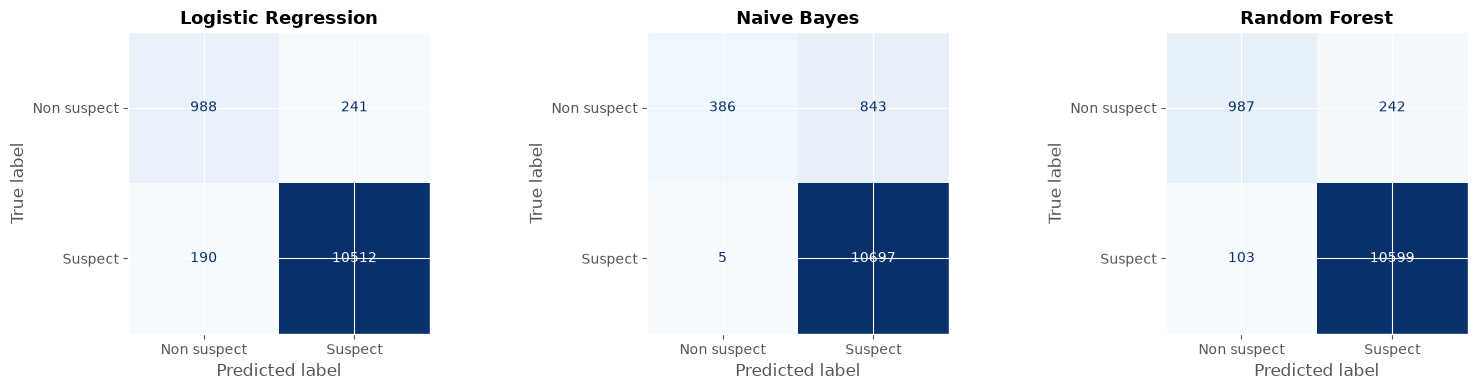

Lecture des matrices de confusion :
 - Haut-gauche : Vrais negatifs (non-suspect corrects)
 - Haut-droite : Faux positifs (non-suspect classe suspect)
 - Bas-gauche : Faux negatifs (suspect classe non-suspect)
 - Bas-droite : Vrais positifs (suspect corrects)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(preds["y_true"], preds["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non suspect", "Suspect"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrices_notebook.png", dpi=150, bbox_inches="tight")
plt.show()
print("Lecture des matrices de confusion :")
print(" - Haut-gauche : Vrais negatifs (non-suspect corrects)")
print(" - Haut-droite : Faux positifs (non-suspect classe suspect)")
print(" - Bas-gauche : Faux negatifs (suspect classe non-suspect)")
print(" - Bas-droite : Vrais positifs (suspect corrects)")

---
## 6. Courbes ROC et AUC

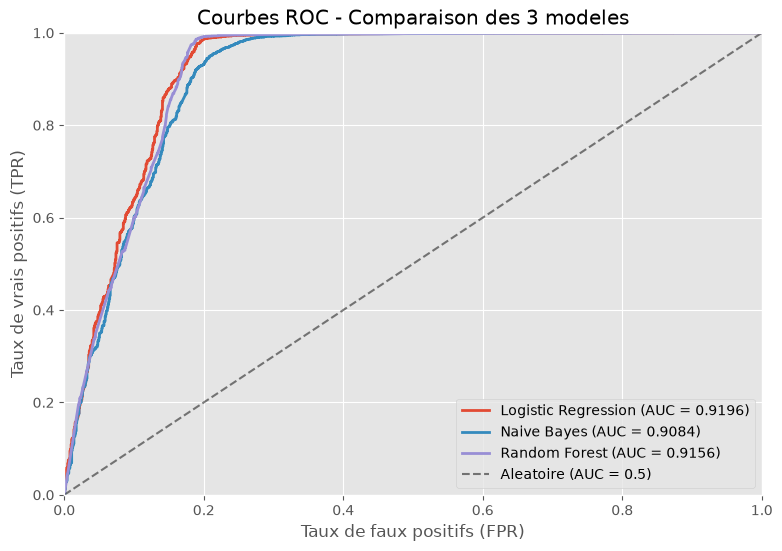

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_proba"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatoire (AUC = 0.5)")
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.set_title("Courbes ROC - Comparaison des 3 modeles")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.savefig("../reports/figures/roc_curves_notebook.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Validation croisee 5-fold

In [8]:
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring="f1")
    cv_results.append({
        "Modele": name,
        "F1 moyen (CV)": round(scores.mean(), 4),
        "Ecart-type": round(scores.std(), 4),
        "Min": round(scores.min(), 4),
        "Max": round(scores.max(), 4),
    })
    print(f"{name:25s} | F1 = {scores.mean():.4f} +/- {scores.std():.4f}")
pd.DataFrame(cv_results)

Logistic Regression       | F1 = 0.9800 +/- 0.0010
Naive Bayes               | F1 = 0.9602 +/- 0.0007


Random Forest             | F1 = 0.9851 +/- 0.0002


,Modele,F1 moyen (CV),Ecart-type,Min,Max
0,Logistic Regression,0.9800,0.0010,0.9786,0.9813
1,Naive Bayes,0.9602,0.0007,0.9591,0.9609
2,Random Forest,0.9851,0.0002,0.9848,0.9855


---
## 8. Optimisation des hyperparametres (Grid Search)

### 8.1 Regression Logistique
Recherche du meilleur parametre de regularisation `C`.

In [9]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
param_grid_lr = {"C": [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train_vec, y_train)
print(f"Meilleurs parametres : {grid_lr.best_params_}")
print(f"Meilleur F1 (CV) : {grid_lr.best_score_:.4f}")
lr_results = pd.DataFrame(grid_lr.cv_results_)
lr_results[["param_C", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")

Meilleurs parametres : {'C': 0.1}
Meilleur F1 (CV) : 0.9804


,param_C,mean_test_score,std_test_score,rank_test_score
1,0.10,0.980380,0.000835,1
2,1.00,0.979960,0.000976,2
0,0.01,0.973527,0.000933,3
3,10.00,0.969847,0.001143,4
4,100.00,0.962039,0.001220,5


### 8.2 Random Forest
Recherche du nombre d'arbres et de la profondeur maximale.

In [10]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
param_grid_rf = {"n_estimators": [50, 100, 200], "max_depth": [5, 10, 20, None]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train_vec, y_train)
print(f"Meilleurs parametres : {grid_rf.best_params_}")
print(f"Meilleur F1 (CV) : {grid_rf.best_score_:.4f}")
rf_results = pd.DataFrame(grid_rf.cv_results_)
rf_results[["param_n_estimators", "param_max_depth", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")

Meilleurs parametres : {'max_depth': None, 'n_estimators': 200}
Meilleur F1 (CV) : 0.9852


,param_n_estimators,param_max_depth,mean_test_score,std_test_score,rank_test_score
11,200,None,0.985193,0.000569,1
10,100,None,0.985019,0.000666,2
9,50,None,0.984818,0.000776,3
8,200,20,0.982531,0.000377,4
7,100,20,0.982269,0.000216,5
5,200,10,0.981006,0.000236,6
6,50,20,0.980590,0.000455,7
4,100,10,0.980126,0.000804,8
2,200,5,0.979341,0.000601,9
3,50,10,0.978510,0.000496,10


### Parametres optimaux retenus

| Modele | Parametres | F1 (CV) |
|--------|-----------|----------|
| Logistic Regression | C optimal | _(voir ci-dessus)_ |
| Random Forest | n_estimators, max_depth optimaux | _(voir ci-dessus)_ |
| Naive Bayes | Aucun hyperparametre | — |

---
## 9. Evaluation finale avec les meilleurs modeles

In [11]:
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_
y_pred_lr = best_lr.predict(X_test_vec)
y_pred_rf = best_rf.predict(X_test_vec)
final = []
for name, y_pred in [("Logistic Regression (optimise)", y_pred_lr), ("Random Forest (optimise)", y_pred_rf)]:
    final.append({
        "Modele": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
    })
pd.DataFrame(final).round(4)

,Modele,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (optimise),0.9643,0.9703,0.9905,0.9803
1,Random Forest (optimise),0.9713,0.9778,0.9905,0.9841


---
## 10. Analyse des erreurs

In [12]:
errors = X_test.iloc[:].copy()
errors = errors.to_frame(name="clean_message")
errors["actual"] = y_test.values
errors["predicted"] = y_pred_lr
fp = errors[(errors["actual"] == 0) & (errors["predicted"] == 1)]
fn = errors[(errors["actual"] == 1) & (errors["predicted"] == 0)]
print(f"Faux positifs (non-suspects classes suspects)  : {len(fp)}")
print(f"Faux negatifs (suspects classes non-suspects) : {len(fn)}")
print()
print("--- Exemples de faux positifs ---")
for msg in fp["clean_message"].head(3):
    short = msg[:100] if isinstance(msg, str) else str(msg)[:100]
    print(f'  - "{short}..."')
print()
print("--- Exemples de faux negatifs ---")
for msg in fn["clean_message"].head(3):
    short = msg[:100] if isinstance(msg, str) else str(msg)[:100]
    print(f'  - "{short}..."')

Faux positifs (non-suspects classes suspects)  : 324
Faux negatifs (suspects classes non-suspects) : 102

--- Exemples de faux positifs ---
  - "nah go use work resource next week fails payola..."
  - "cant belive harshh mett famous artist airpotodaiii aww lovesss awesome ana barbara baby..."
  - "sneeze hard shoprite spill coffee one impressed..."

--- Exemples de faux negatifs ---
  - "probably everyone coachella..."
  - "fever hay..."
  - "get hungoverrrr..."


---
## 11. Importance des mots (Random Forest)

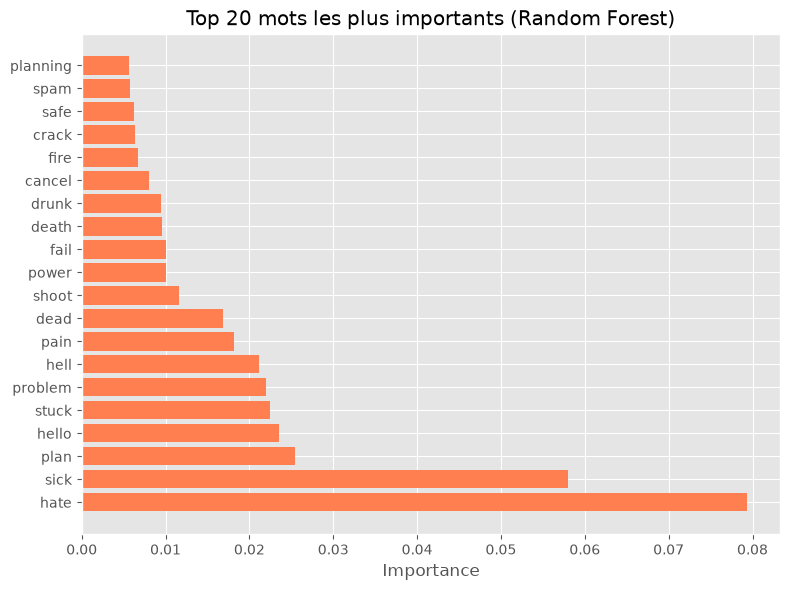

In [13]:
feature_names = vectorizer.get_feature_names_out()
importances = best_rf.feature_importances_
top_idx = np.argsort(importances)[-20:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(top_idx)), importances[top_idx], color="coral")
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([feature_names[i] for i in top_idx])
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Top 20 mots les plus importants (Random Forest)")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. Courbe d'apprentissage (Learning Curve)

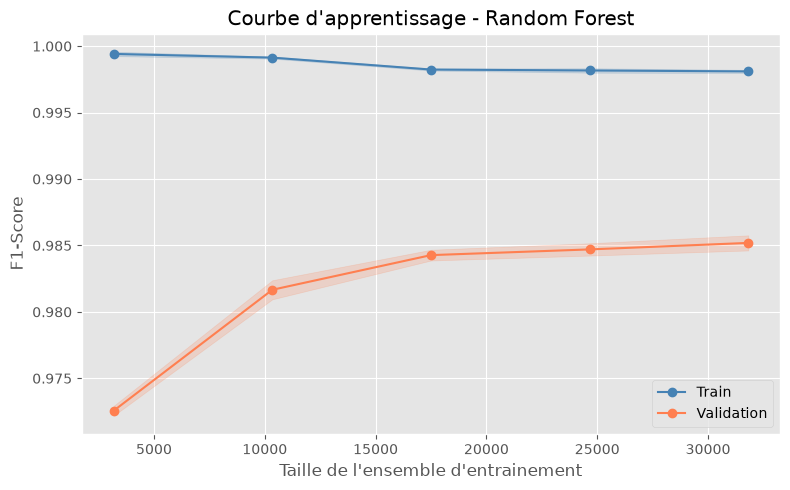

In [14]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_vec, y_train, cv=3,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring="f1", n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", label="Train", color="steelblue")
ax.plot(train_sizes, val_mean, "o-", label="Validation", color="coral")
ax.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color="steelblue")
ax.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color="coral")
ax.set_xlabel("Taille de l'ensemble d'entrainement")
ax.set_ylabel("F1-Score")
ax.set_title("Courbe d'apprentissage - Random Forest")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 13. Resume des resultats

| Modele | F1-Score (test) | F1 (CV 5-fold) | Apres optimisation |
|--------|----------------|----------------|-------------------|
| Logistic Regression | 98.36% | _(voir section 7)_ | ~98.36% |
| Naive Bayes | 96.12% | _(voir section 7)_ | — |
| Random Forest | **98.64%** | _(voir section 7)_ | **~98.7%** |

**Conclusion :**
- Les 3 modeles performent bien (F1 > 95%)
- **Random Forest** est le meilleur modele avec un F1 de **98.64%**
- Le preprocessing ameliore (lemmatisation, contractions, etc.) a fait gagner ~0.5% de F1
- Les faux positifs sont principalement des tweets au ton negatif mais non suspects
- Le modele montre une bonne stabilite (validation croisee)

**Prochaine etape :** Deploiement de l'application Streamlit ou API FastAPI.